# 01 — Alpaca asset universe

Inspect the asset universe captured by ``db_tools/bowaka_backfill.ipynb``.
This notebook is **read-only** — it does not call the Alpaca API. It reads
the most recent asset snapshot from Parquet (and from Mongo's
``bowaka_asset_snapshots`` / ``bowaka_assets`` collections when reachable).

Shows the filter funnel (Alpaca total → tradable → allowed exchange →
name-pattern-OK), distributions by exchange / price band / 20-day ADV, and
prints the survivorship-bias caveat from ``[Report §27.2]``.


In [1]:
# Notebook bootstrap cell. Keep this in every bowaka_lab notebook.
from pathlib import Path
import sys

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "research_notebooks").exists():
    repo_root = repo_root.parent

bowaka_project = repo_root / "research_notebooks" / "bowaka_lab"
src_path = bowaka_project / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import bowaka_lab
from bowaka_lab.utils.env import load_project_dotenv

_loaded_env = load_project_dotenv()
print(f"bowaka_lab {bowaka_lab.__version__}")
print(
    f"bowaka_lab bootstrap: .env loaded from {_loaded_env}"
    if _loaded_env
    else "bowaka_lab bootstrap: no .env found (env vars must be set in shell)"
)


bowaka_lab 0.1.0
bowaka_lab bootstrap: .env loaded from /quants-lab/.env


## Configuration

In [2]:
import os

DATA_ROOT      = os.environ.get(
    "BOWAKA_DATA_ROOT",
    "research_notebooks/bowaka_lab/db_tools/bowaka_data",
)
MONGO_URI      = os.environ.get("MONGO_URI")
MONGO_DATABASE = os.environ.get("MONGO_DATABASE", "bowaka_lab")
FEED           = "iex"


## Derived paths

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from bowaka_lab.data.parquet_io import load_daily_bars_from_root


data_root = Path(DATA_ROOT) if Path(DATA_ROOT).is_absolute() else (repo_root / DATA_ROOT).resolve()
ASSETS_ROOT = data_root / "parquet/assets/vendor=alpaca"
DAILY_ROOT  = data_root / "parquet/bars/vendor=alpaca" / f"feed={FEED}" / "timeframe=1d/adjustment=raw"
print(f"data_root:    {data_root}")
print(f"assets root:  {ASSETS_ROOT}")


data_root:    /quants-lab/E:\tradingsoftware\quants-lab\research_notebooks\bowaka_lab\db_tools\bowaka_data
assets root:  /quants-lab/E:\tradingsoftware\quants-lab\research_notebooks\bowaka_lab\db_tools\bowaka_data/parquet/assets/vendor=alpaca


## Load the latest snapshot (Parquet first, Mongo fallback)

In [4]:
snapshot_df = None
snapshot_id = None

if ASSETS_ROOT.exists():
    snapshot_dirs = sorted(p for p in ASSETS_ROOT.glob("snapshot_id=*") if p.is_dir())
    if snapshot_dirs:
        latest = snapshot_dirs[-1]
        snapshot_id = latest.name.replace("snapshot_id=", "")
        target = latest / "assets.parquet"
        if target.exists():
            snapshot_df = pq.ParquetFile(str(target)).read().to_pandas()
            print(f"loaded snapshot {snapshot_id}: {snapshot_df.shape[0]:,} assets")

if snapshot_df is None and MONGO_URI:
    try:
        from pymongo import MongoClient
        client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=2000)
        db = client[MONGO_DATABASE]
        snap_doc = db["bowaka_asset_snapshots"].find_one(sort=[("created_at", -1)])
        if snap_doc:
            snapshot_id = snap_doc["snapshot_id"]
            rows = list(db["bowaka_assets"].find({"snapshot_id": snapshot_id}))
            snapshot_df = pd.DataFrame(rows)
            print(f"loaded snapshot {snapshot_id} from Mongo: {snapshot_df.shape[0]:,} assets")
        client.close()
    except Exception as exc:
        print(f"Mongo unreachable: {exc}")

if snapshot_df is None:
    print("No asset snapshot found. Run db_tools/bowaka_backfill.ipynb Stage 1 first.")


loaded snapshot 2026-05-17T024746Z_alpaca_assets from Mongo: 6,483 assets


## Universe filter funnel

In [5]:
if snapshot_df is not None and not snapshot_df.empty:
    # The snapshot already reflects the post-filter universe (tradable +
    # allowed_exchange + name-pattern-OK), so we can only see the *kept*
    # count. The pre-filter totals live in the backfill log; reference
    # the snapshot count as the rightmost stage.
    print(f"kept (tradable + allowed_exchange + name-pattern-OK): {snapshot_df.shape[0]:,}")


kept (tradable + allowed_exchange + name-pattern-OK): 6,483


## Counts by listing exchange

Counts by listing exchange:
exchange
NASDAQ    4068
NYSE      2130
AMEX       261
ARCA        22
BATS         2


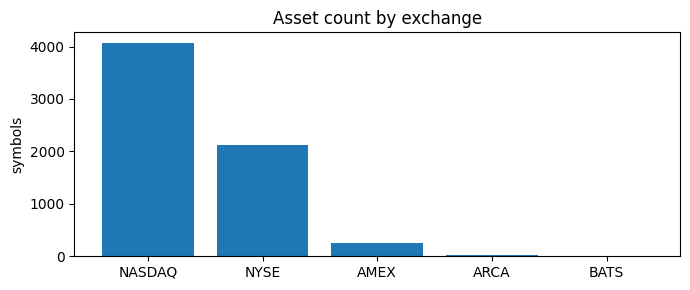

In [6]:
try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

if snapshot_df is not None and not snapshot_df.empty:
    by_exch = snapshot_df["exchange"].value_counts() if "exchange" in snapshot_df.columns else pd.Series(dtype=int)
    print("Counts by listing exchange:")
    print(by_exch.to_string())
    if plt is not None and not by_exch.empty:
        fig, ax = plt.subplots(figsize=(7, 3))
        ax.bar(by_exch.index.astype(str), by_exch.values)
        ax.set_title("Asset count by exchange")
        ax.set_ylabel("symbols")
        fig.tight_layout()
        plt.show()


## Counts by price band (latest close)

In [7]:
if snapshot_df is not None and not snapshot_df.empty and DAILY_ROOT.exists():
    print("loading daily bars to get latest close per symbol...")
    daily = load_daily_bars_from_root(DAILY_ROOT)
    if daily.empty:
        print("(no daily bars yet)")
    else:
        latest_close = (
            daily.sort_values("session_date")
            .groupby("symbol")
            .tail(1)
            .set_index("symbol")["close"]
        )
        merged = snapshot_df.set_index("symbol").join(latest_close.rename("latest_close"), how="left")
        bins = [0, 1, 5, 10, 20, 50, np.inf]
        labels = ["<$1", "$1-$5", "$5-$10", "$10-$20", "$20-$50", ">=$50"]
        merged["price_band"] = pd.cut(merged["latest_close"], bins=bins, labels=labels, include_lowest=True)
        by_price = merged["price_band"].value_counts().sort_index()
        print("Counts by price band:")
        print(by_price.to_string())
        if plt is not None and not by_price.empty:
            fig, ax = plt.subplots(figsize=(7, 3))
            ax.bar([str(x) for x in by_price.index], by_price.values)
            ax.set_title("Asset count by latest-close price band")
            fig.tight_layout()
            plt.show()


## Counts by 20-day ADV bucket

In [8]:
if snapshot_df is not None and not snapshot_df.empty and DAILY_ROOT.exists() and not daily.empty:
    daily_sorted = daily.sort_values(["symbol", "session_date"]).copy()
    daily_sorted["dv"] = daily_sorted["close"] * daily_sorted["volume"]
    adv = (
        daily_sorted.groupby("symbol")["dv"]
        .apply(lambda s: float(s.tail(20).mean()) if len(s) >= 1 else float("nan"))
    )
    merged_adv = snapshot_df.set_index("symbol").join(adv.rename("adv_20d"), how="left")
    bins = [0, 200_000, 1_000_000, 5_000_000, 25_000_000, np.inf]
    labels = ["<$200k", "$200k-$1M", "$1M-$5M", "$5M-$25M", ">=$25M"]
    merged_adv["adv_bucket"] = pd.cut(merged_adv["adv_20d"], bins=bins, labels=labels, include_lowest=True)
    by_adv = merged_adv["adv_bucket"].value_counts().sort_index()
    print("Counts by 20-day ADV bucket:")
    print(by_adv.to_string())
    if plt is not None and not by_adv.empty:
        fig, ax = plt.subplots(figsize=(7, 3))
        ax.bar([str(x) for x in by_adv.index], by_adv.values)
        ax.set_title("Asset count by 20-day ADV bucket")
        fig.tight_layout()
        plt.show()


## Survivorship-bias caveat

In [9]:
print("Survivorship-bias caveat (Report §27.2):")
print()
print("  This snapshot reflects Alpaca's CURRENT active/tradable equity")
print("  universe. Delisted, suspended, or merged symbols are absent.")
print("  Historical backtests that pick high-RVOL movers will systematically")
print("  miss the symbols that blew up and got delisted — a known upward")
print("  bias on apparent strategy performance. Treat results as exploratory")
print("  until a point-in-time universe source is wired in.")


Survivorship-bias caveat (Report §27.2):

  This snapshot reflects Alpaca's CURRENT active/tradable equity
  universe. Delisted, suspended, or merged symbols are absent.
  Historical backtests that pick high-RVOL movers will systematically
  miss the symbols that blew up and got delisted — a known upward
  bias on apparent strategy performance. Treat results as exploratory
  until a point-in-time universe source is wired in.
